# 第 06 章 聚类与质量复核

## 学习目标

比较聚类分辨率，并结合双细胞分数及 QC 指标检查群体结构。

## 为什么做与怎样做

在所选邻居图上运行分辨率 0.02、0.50、1.00、2.00 的 Leiden 聚类。以指标和标记基因为依据解释簇，不把簇编号当作细胞类型。

前置章节：05。运行前请完成项目环境准备。


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import sys
ROOT = Path(os.environ.get("SC_COURSE_ROOT", Path.cwd())).resolve()
while not (ROOT / "config/course.json").is_file() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config/course.json").is_file():
    raise RuntimeError("请从课程目录或其 notebooks/exercises 目录运行。")
os.environ["CELLTYPIST_FOLDER"] = str(ROOT / ".runtime/celltypist")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".runtime/matplotlib")
sys.path.insert(0, str(ROOT / "tools"))
from course_runtime import start_chapter, marker_sets, scaled_view
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
ctx = start_chapter("06")
adata = ctx.load_input()


第 06 章：聚类与质量复核
结果目录：results/06_clustering/20260915T073923_fe681c


读取检查点：results/05_integration/20260915T073407_99a665/checkpoint.h5ad
17,041 个细胞 × 23,427 个基因


## 06.1 聚类

与 Seurat 等框架类似，推荐使用 Leiden 图聚类方法（基于优化模块度的社区发现）（参考文献：Traag2019）。注意 Leiden 聚类直接对上一节计算的细胞邻近图进行聚类。

Louvain	通过不断尝试将节点移到邻居社区，来最大化整个网络的“模块度”（衡量社区内连接紧密、社区间连接稀疏的指标）。	sc.tl.louvain(adata, resolution=0.8)	在 adata.obs 中生成新列（如 'louvain'），值为 '0', '1', '2'...，代表每个细胞的聚类标签。

Leiden	Louvain的改进版。能保证分出更连通、更稳定的社群，速度更快，是现代单细胞分析的首选。	sc.tl.leiden(adata, resolution=0.8)	同上，生成列如 'leiden'。关键参数 resolution：值越大（如1.5），分出的簇越多、越细；值越小（如0.3），簇越少、越粗。现在让我们生成一组不同分辨率的聚类结果，用于随后用于细胞类型注释。这里使用 Leiden 算法。

## 06.2 使用leiden聚类

In [2]:
# 功能说明：更新图形输出目录。
# 运行目的：将聚类分析相关的图片保存到 `figures/3. 聚类` 文件夹。
# 详细代码解析：
# 1. `sc.settings.figdir = ...`
#    - 设置新的输出路径。

# 设置输出目录
sc.settings.figdir = ctx.figures

In [3]:
# 功能说明：以不同分辨率生成多套 Leiden 聚类标签。
# 运行目的：提供粗到细的多粒度簇划分，用于后续手动注释。
# 变量/函数/参数解析：
# - for res in ：遍历分辨率列表。
# sc.tl.leiden: scanpy的Leiden聚类函数，基于igraph实现
    # adata: AnnData对象，包含单细胞数据
    # key_added=f"leiden_res_{res:4.2f}": 指定聚类结果保存的列名
    #   f-string格式化：res:4.2f 表示总宽度4，保留2位小数
    #   res=0.02 -> "leiden_res_0_02"
    #   res=0.5  -> "leiden_res_0_50" (自动补0)
    #   res=1    -> "leiden_res_1_00"
    #   res=2.0  -> "leiden_res_2_00"
    # resolution=res: Leiden聚类的分辨率参数
    #   值越大，聚类结果越多（细胞被分为更多cluster）
    #   值越小，聚类结果越少（细胞被分为更少cluster）
    # flavor="igraph": 使用igraph库的Leiden算法实现
resolution_list = ctx.config["parameters"]["resolutions"]
for res in resolution_list:
    column_name = f"leiden_res_{res:4.2f}".replace('.', '_')
    sc.tl.leiden(adata, key_added=column_name, resolution=res, flavor="igraph", n_iterations=-1, directed=False, random_state=0, neighbors_key=adata.uns["course_neighbors_key"])

需要注意，簇的数量在很大程度上是任意的，`resolution` 参数仅用于调节它。最终合理的簇数应以稳定且有生物学意义的群体为准，通常由领域专家或基于专家整理的标记知识来判定。

In [4]:
# 功能说明：查看 AnnData 对象的摘要信息。
# 运行目的：确认 Leiden 聚类后，`obs` 中是否添加了不同分辨率的聚类标签列（如 `leiden_res_0_02`）。
# 详细代码解析：
# 1. `adata`
#    - 打印概览。
#    - `obs` 应包含多个 `leiden_res_...` 列。

adata

AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'samples', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0_02', 'leiden_res_0_50', 'leiden_res_1_00', 'leiden_res_2_00'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_pca_bbknn', 'X_pca_harmony', 'course_neighbors_key', 'hvg', 'log1p', 'neighbors', 'pca', 'samples_colors', 'scrub

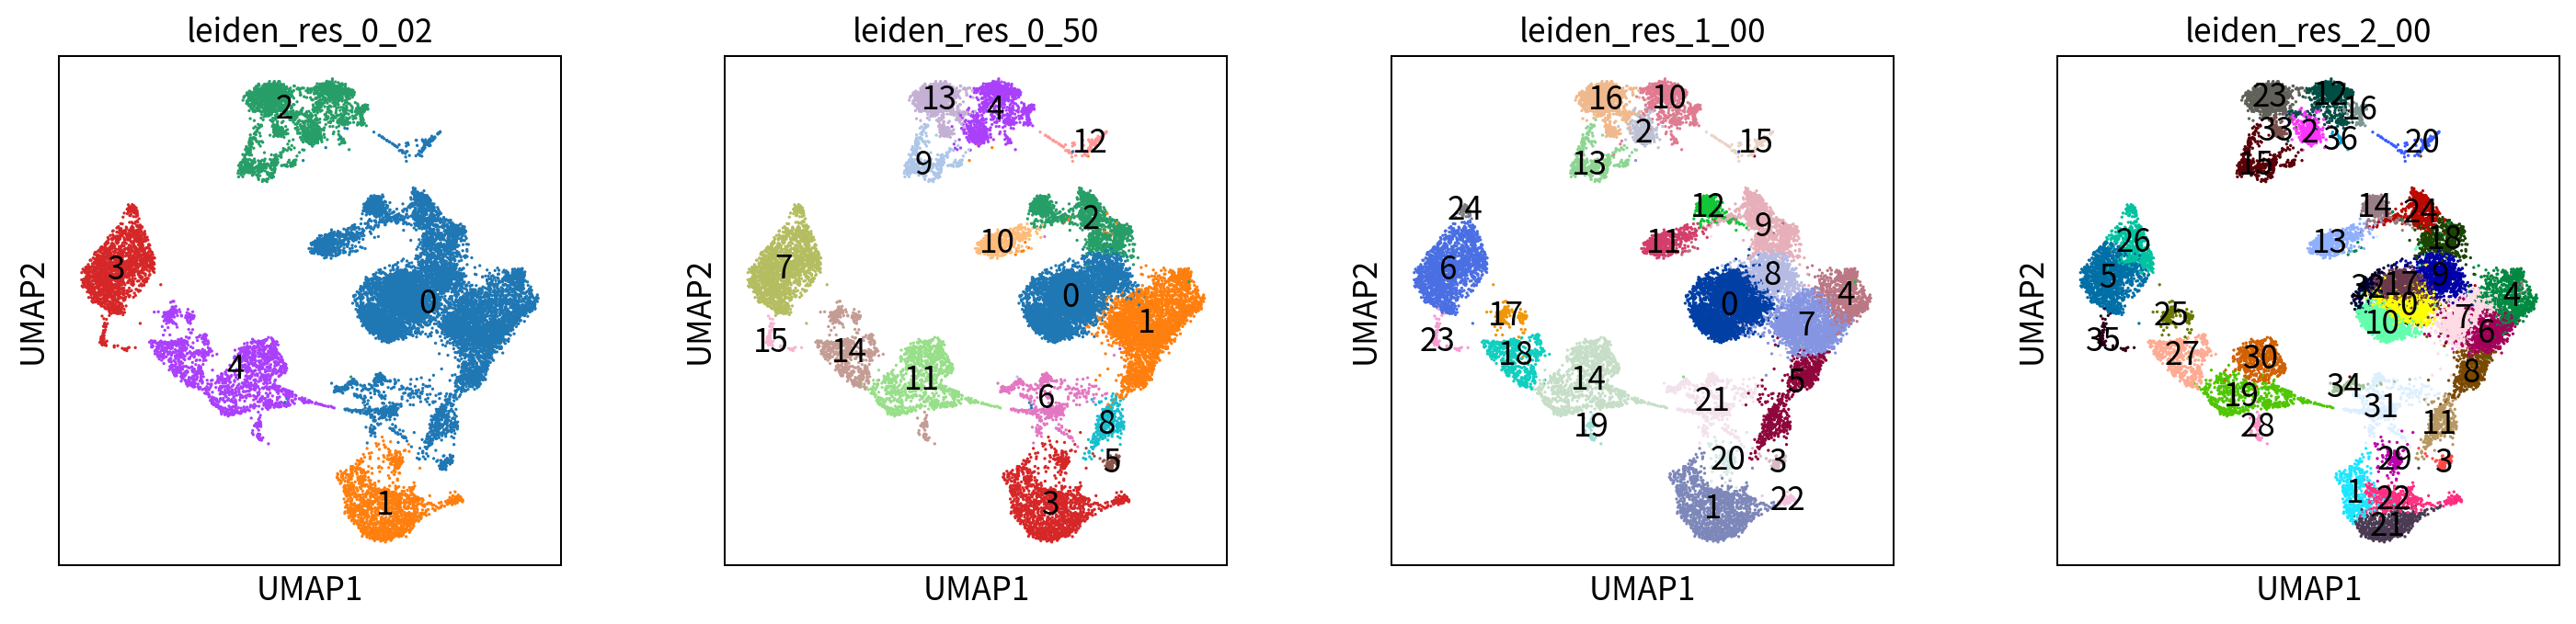

In [5]:
# 功能说明：在 UMAP 上按 Leiden 聚类标签着色。
# 运行目的：直观查看聚类结果与空间结构。
sc.pl.umap(
    adata,
    color=["leiden_res_0_02", "leiden_res_0_50","leiden_res_1_00", "leiden_res_2_00"],
    legend_loc="on data",
    save="_06_152.pdf",
)

In [6]:
# 功能说明：统计不同分辨率下的聚类细胞数量。
# 运行目的：观察不同分辨率下簇的数量和大小分布，评估聚类的粒度。
# 详细代码解析：
# 1. `resolution_list = [...]`
#    - 定义要检查的分辨率列表。
# 2. `for res in resolution_list:`
#    - 遍历每个分辨率。
# 3. `column_name = ...`
#    - 构造对应的列名（如 `leiden_res_0_50`）。
# 4. `print(adata.obs[column_name].value_counts())`
#    - `adata.obs[column_name]`: 获取聚类标签列。
#    - `.value_counts()`: 统计每个簇的细胞数量。
#    - `print(...)`: 打印统计结果。

# 查看每个类群细胞数量
resolution_list = ctx.config["parameters"]["resolutions"]
for res in resolution_list:
    column_name = f"leiden_res_{res:4.2f}".replace('.', '_')
    print(adata.obs[column_name].value_counts())

leiden_res_0_02
0    9765
2    2268
3    1760
4    1740
1    1508
Name: count, dtype: int64
leiden_res_0_50
0     3946
1     3101
7     1695
3     1511
2     1260
11    1057
4      977
13     914
14     685
6      502
10     458
9      382
8      298
12     106
5       84
15      65
Name: count, dtype: int64
leiden_res_1_00
0     3000
7     1863
6     1620
1     1320
14    1058
9      955
8      923
16     918
5      793
4      754
10     668
21     490
18     477
11     459
13     387
12     326
2      302
17     148
20     119
15     105
3       84
22      72
24      71
23      68
19      61
Name: count, dtype: int64
leiden_res_2_00
5     1182
10    1037
0     1028
7      970
9      872
17     820
6      793
4      779
23     763
21     574
19     559
12     555
18     522
8      517
26     509
30     499
27     477
13     460
24     455
22     443
31     422
15     394
1      375
14     327
2      316
11     300
32     171
25     148
29     119
33     115
16     109
20     106
3    

## 06.3 重新评估质量控制与细胞过滤

如前所述，我们将通过 UMAP 可视化不同 QC 指标来重新评估过滤策略。

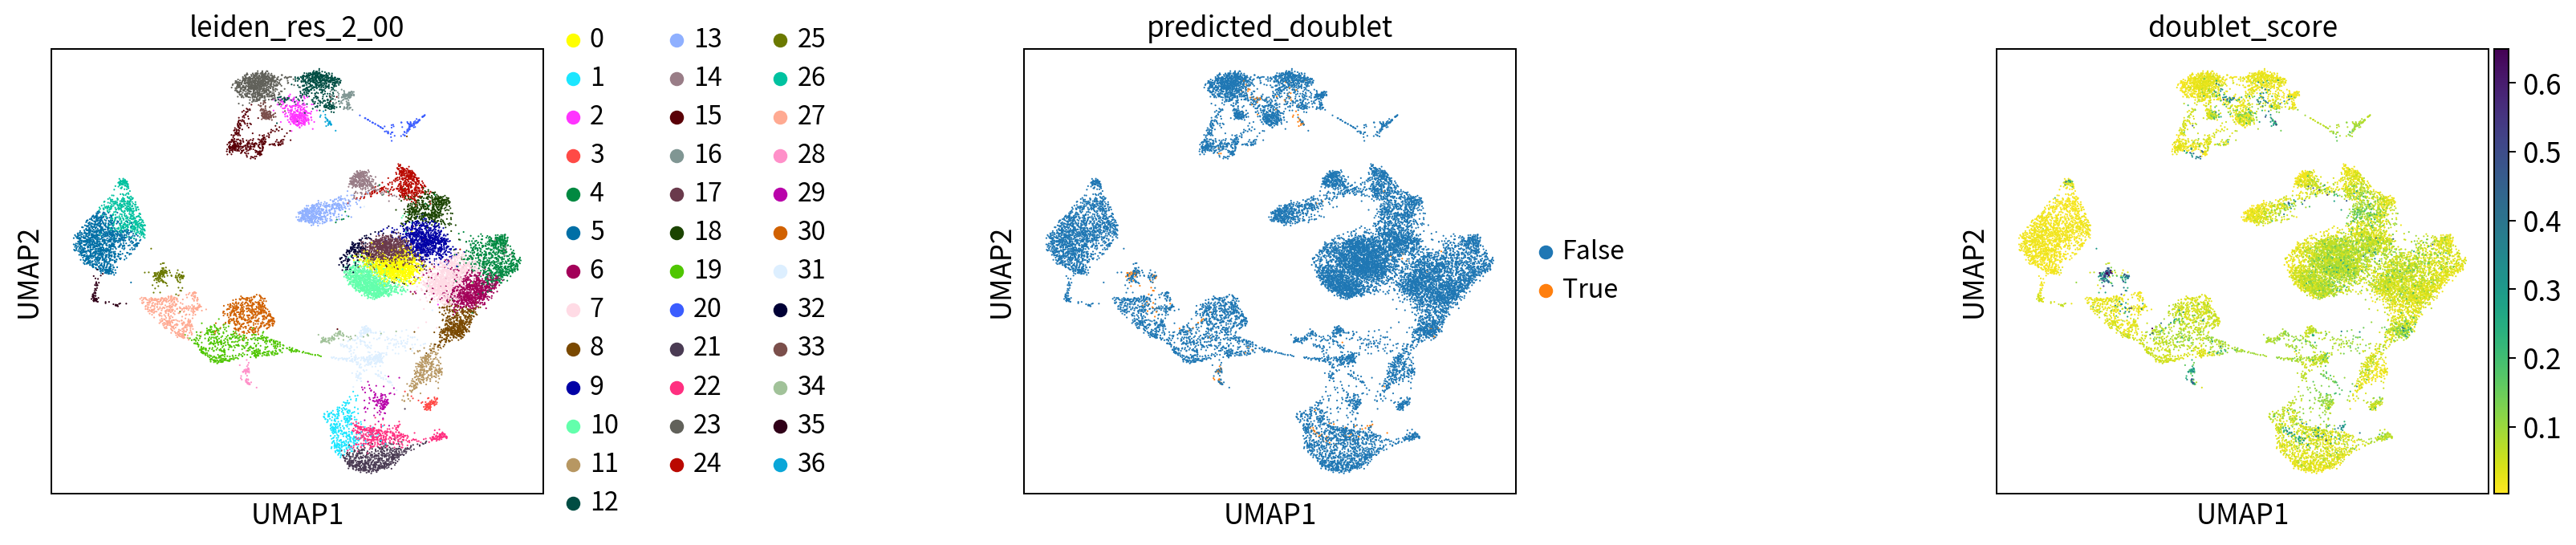

In [7]:
# 功能说明：将聚类标签与双细胞预测结果在 UMAP 上联合展示。
# 运行目的：辅助判断是否需要根据双细胞分数或预测进行进一步过滤。
# 变量/函数/参数解析：
# - sc.pl.umap(adata, color=["leiden", "predicted_doublet", "doublet_score"], wspace=0.5, size=3)：
#   - color(list)：依次绘制聚类标签、双细胞布尔标记、双细胞分数。
#   - wspace(float)：面板间水平间距。
#   - size(float)：点大小。
sc.pl.umap(
    adata,
    color=["leiden_res_2_00", "predicted_doublet", "doublet_score"],
    # 增加面板间的水平间距
    wspace=0.8,
    size=3,
    save="_06_155.pdf",
)


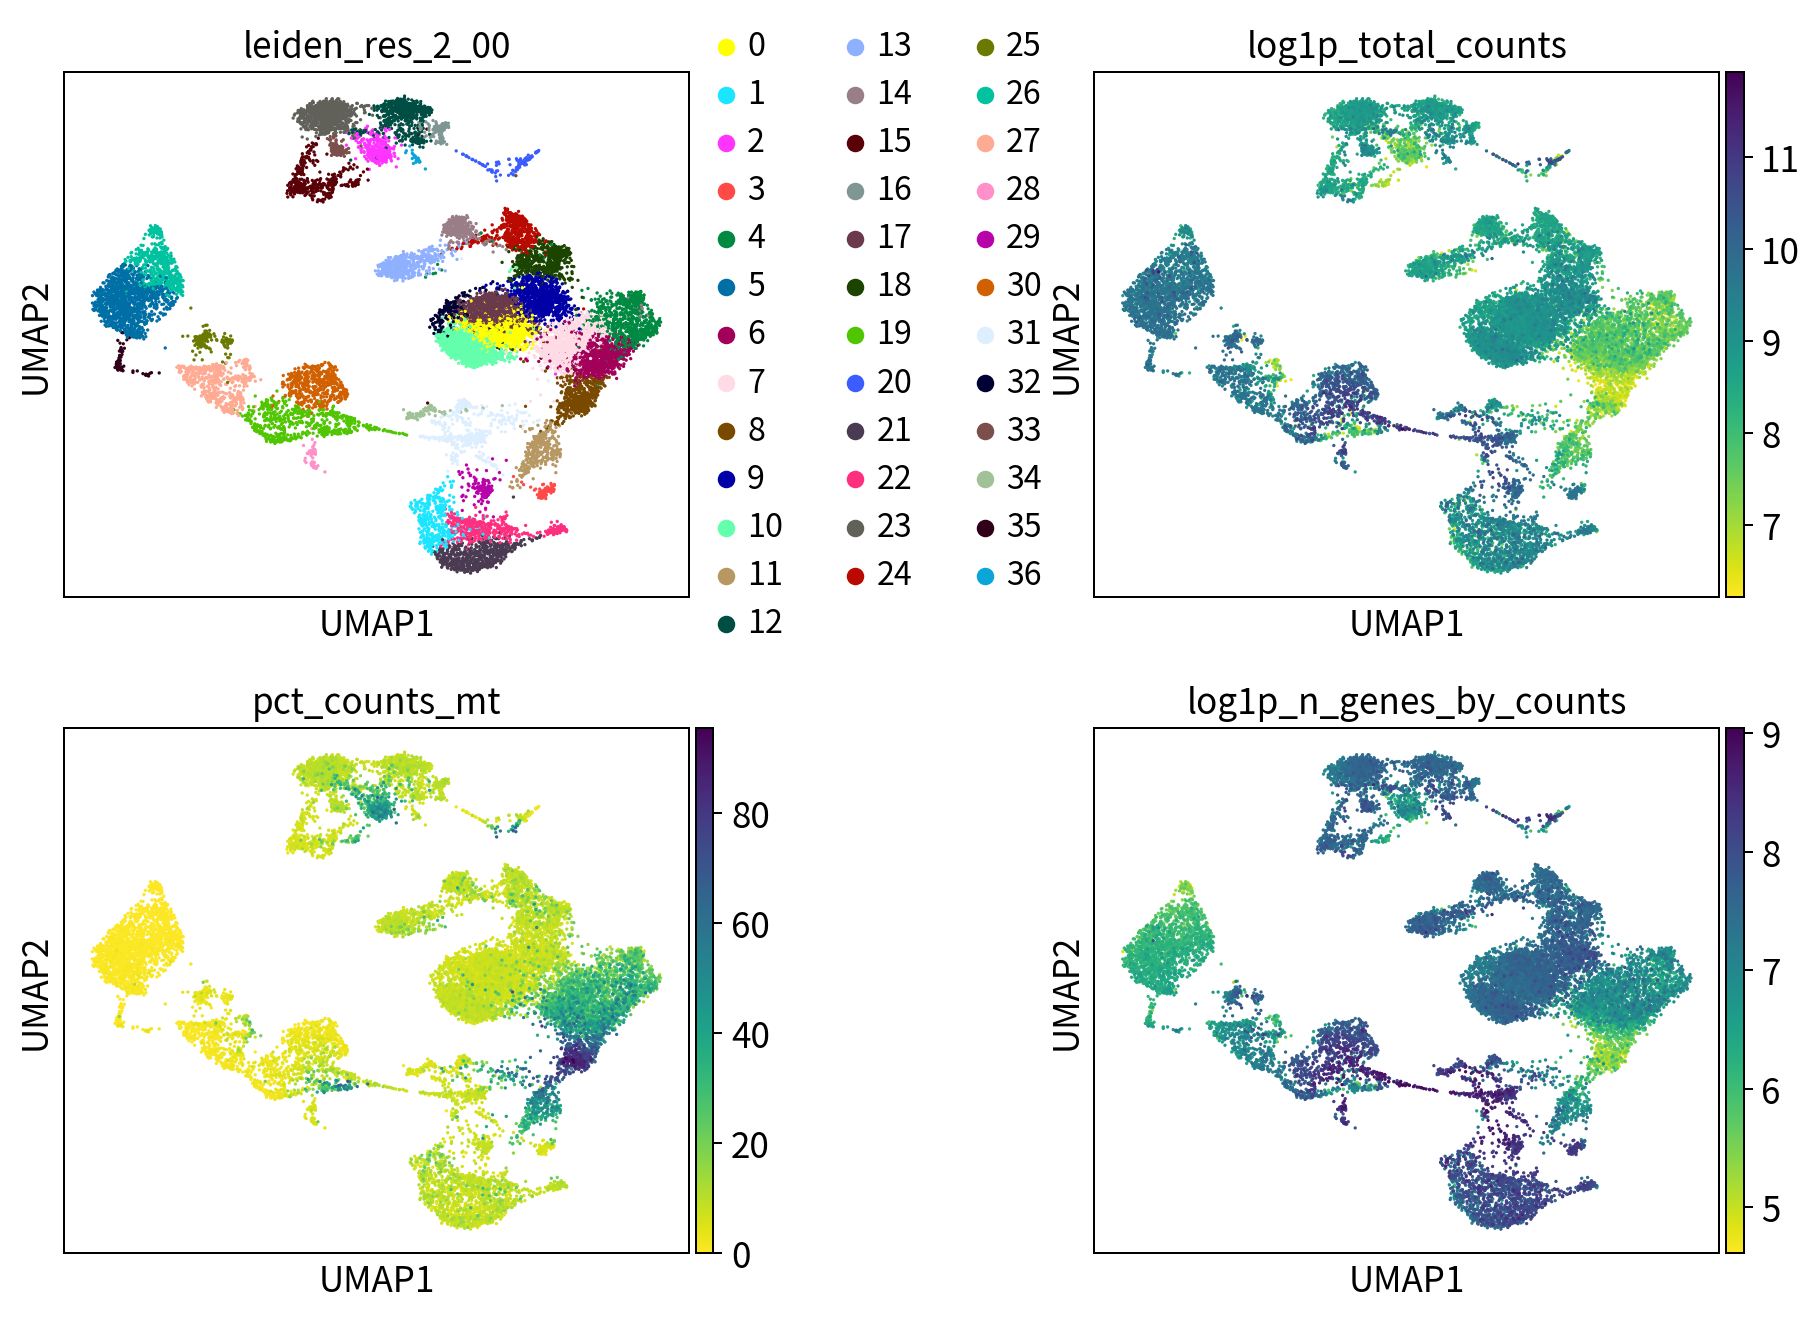

In [8]:
# 功能说明：在 UMAP 上查看关键 QC 指标的空间分布。
# 运行目的：直观评估是否存在由计数或基因数驱动的结构性偏差。
# 变量/函数/参数解析：
# - color=["leiden", "log1p_total_counts", "pct_counts_mt", ""]：
#   - 显示聚类标签、对数化总计数、线粒体占比、对数化基因数。
# - wspace=0.5, ncols=2：
sc.pl.umap(
    adata,
    color=["leiden_res_2_00", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
    save="_06_156.pdf",
)

结合聚类与 QC 指标重新评估质量

## 06.4 进一步过滤的考虑

如果某个群体同时表现出异常 QC 和不合理的标记基因组合，可以提出过滤方案。不要因某个固定簇编号或单一指标直接删除细胞。决定调整过滤时，从第 02 章修改有依据的策略并重新运行后续章节。

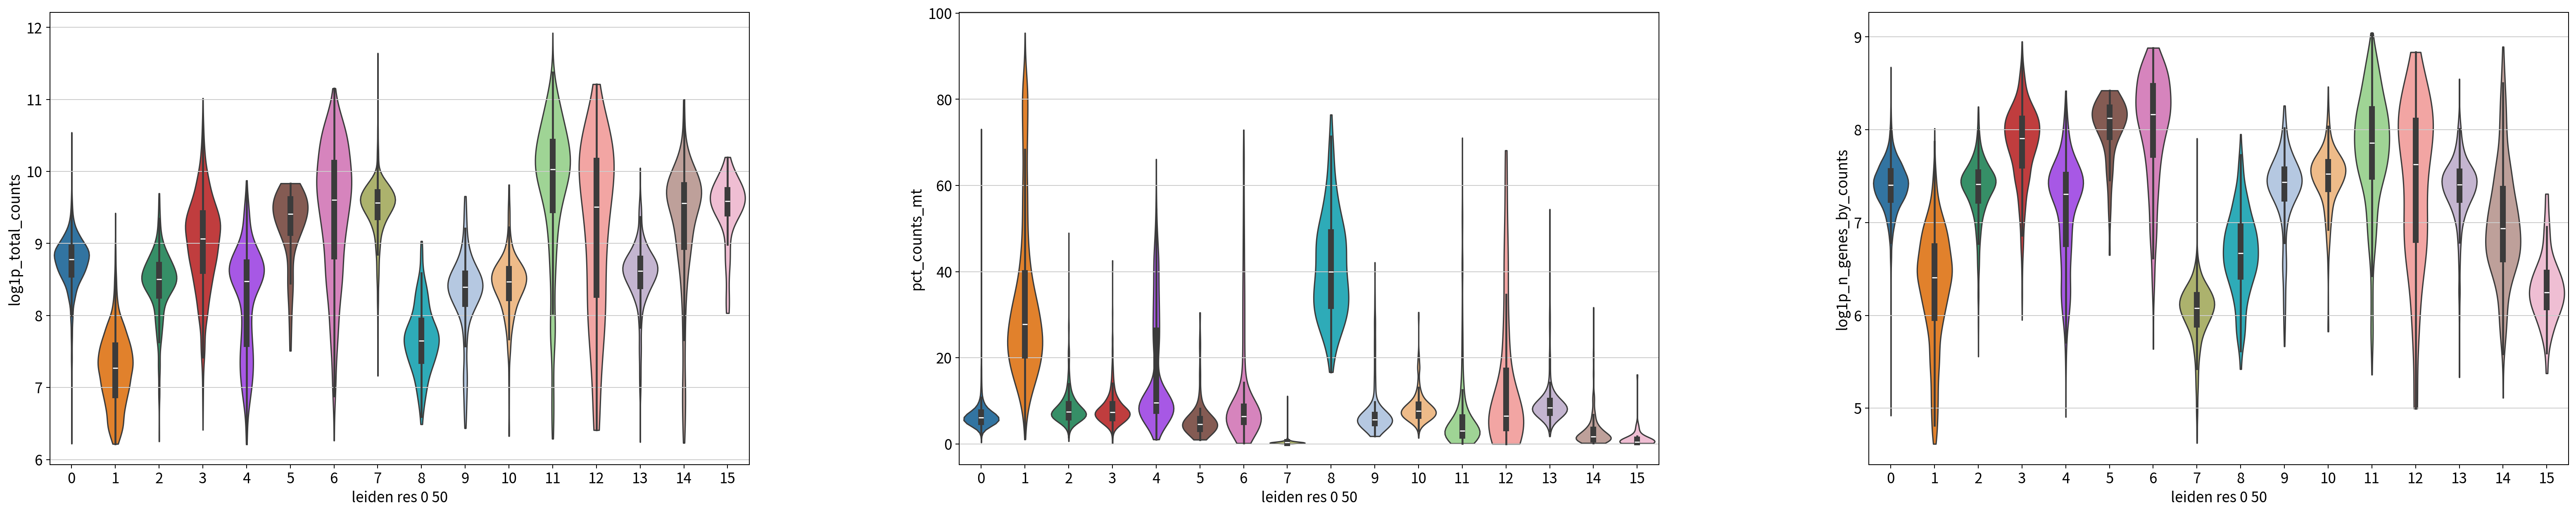

In [9]:
# 功能说明：在 小提琴图上查看关键 QC 指标的空间分布。

with rc_context({"figure.figsize": (10, 8)}):
    sc.pl.violin(
        adata,
        keys = [ "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts", "pct_counts_mt",],
        groupby="leiden_res_0_50",
        stripplot=False,  # 移除内部的点
        inner="box",  # 在小提琴内部添加箱线图
        save="_06_159.pdf",
    )

## 06.5 细胞类型注释

:::{note}
本节在 scverse 教程中有更详细的扩展内容（如自动分配与基因富集），详见[这里](https://scverse-tutorials.readthedocs.io/en/latest/notebooks/basic-scrna-tutorial.html#cell-type-annotation)。
:::

细胞类型注释是一项繁琐而重复的工作，通常需要多轮聚类与重新注释。

我们现在已获得质量尚可的一组细胞，可以继续注释其对应的已知细胞类型。通常使用仅在某类细胞中表达的基因（即标记基因）来区分数据中的异质性群体。已有工作收集并整理了标记基因资源，如 [CellMarker](http://bio-bigdata.hrbmu.edu.cn/CellMarker/)、[TF-Marker](http://bio.liclab.net/TF-Marker/) 与 [PanglaoDB](https://panglaodb.se/)。此外，[cellxgene 基因表达工具](https://cellxgene.cziscience.com/gene-expression)也能帮助查看某基因在多个数据集中的细胞类型表达情况。

标记通常表达稀疏，即通常只有在细胞类型的一部分细胞中检测到标记。这是由于 scRNA-seq 数据的性质：我们只对细胞中 RNA 分子总量的一小部分进行测序，由于这种二次采样，我们有时不会从细胞中的特定基因采样转录本，即使它们在该细胞中表达。因此，我们不会基于例如一组标记的最小表达阈值来注释单个细胞。相反，我们首先通过聚类将数据细分为相似细胞组（即“划分”数据），从而解决单个基因的“缺失转录本”问题，而是基于整体转录组相似性进行分组。然后我们可以根据其整体标记表达模式注释这些聚类。

常见做法是在完成细胞聚类后再使用标记基因进行注释。且需要结合数据情况选择合适的分辨率

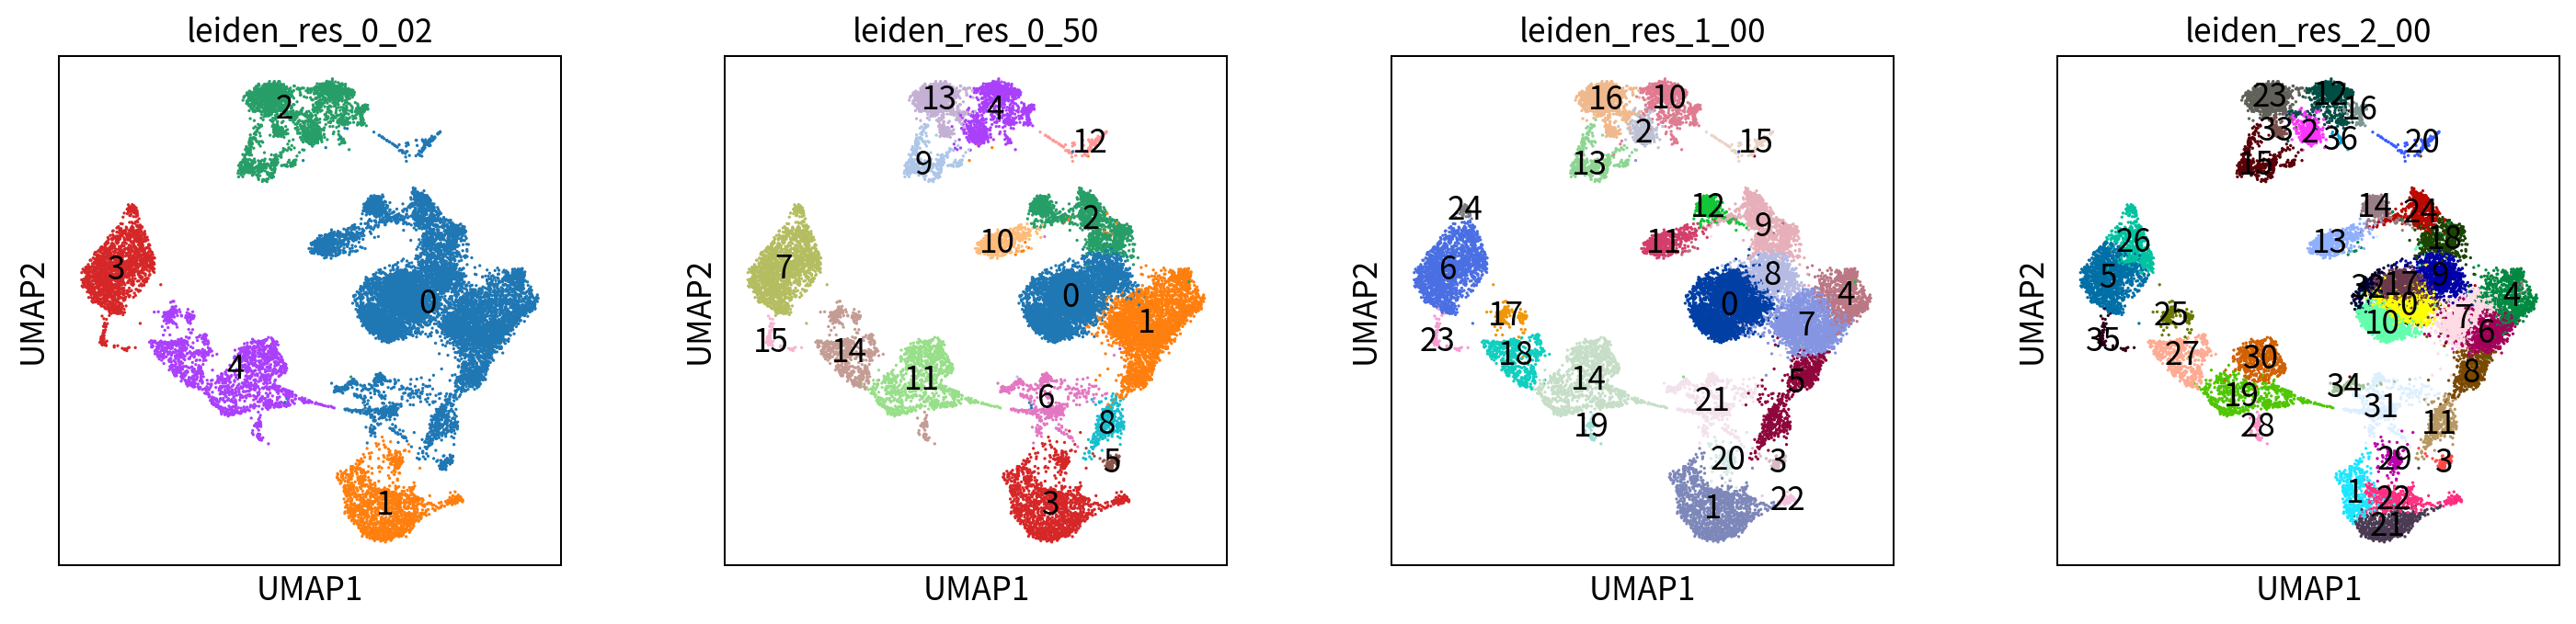

In [10]:
# 功能说明：在 UMAP 上比较不同分辨率的聚类方案。
# 运行目的：选择更适合后续注释的簇粒度。
# 变量/函数/参数解析：
# - legend_loc="on data"：在图中直接显示图例标签。
sc.pl.umap(
    adata,
    color=["leiden_res_0_02", "leiden_res_0_50","leiden_res_1_00", "leiden_res_2_00"],
    legend_loc="on data",
)

虽然不应过度解读 UMAP，但此处可以看到在最高分辨率下数据可能被过度聚类，而最低分辨率可能将不同细胞身份合并到同一簇中。我们可以暂且选择0.5做注释,但在此之前，我们可以先尝试做一下低分辨率的注释，以提前熟悉数据和流程

## 保存本章结果

保存表格、参数摘要和可供后续章节读取的数据。

In [11]:
from course_runtime import cluster_digest
for key in [c for c in adata.obs if c.startswith("leiden_res_")]:
    ctx.table(key + "_by_sample", pd.crosstab(adata.obs[key], adata.obs["samples"]))
    ctx.table(key + "_qc", adata.obs.groupby(key, observed=True)[["pct_counts_mt", "total_counts", "doublet_score", "predicted_doublet"]].mean())
ctx.table("clusters", adata.obs)
ctx.finish(adata, {"clusters": {k: int(adata.obs[k].nunique()) for k in adata.obs if k.startswith("leiden_res_")}, "cluster_fingerprints": {k: cluster_digest(adata, k) for k in ["leiden_res_0_02", "leiden_res_0_50"]}})

本章计算完成。请阅读本次图表和表格，再更新本章解读。


## 结果阅读与思考

请打开本次结果目录中的 summary.json、tables 和 figures。将目的、方法、结果和解释写入本章报告源稿，再更新 Word。

思考题：如何区分细分群体与受低质量细胞驱动的聚类？

运行与报告操作见课程根目录的 99_运行与AI协作指南.md。